# Assignment
Build the AlexNet architecture and train it on the CIFAR10 dataset.

You may resize some of the kernel sizes (mainly the first one) and the number of kernels because CIFAR100 is a smaller dataset than ImageNet, as well as lower-resolution (32x32 vs 224x224).

You may resize the number of kernels used per layer if it speeds up training and/or preserves accuracy. The exact AlexNet architecture and number of units will not work.

Report training, validation and test errors. Which hyperparameters did you change to improve performance?

**MAKE SURE YOU USE A GPU!** Top menu select "Runtime", then "Runtime Type". Make sure "Hardware Accelerator" has the option "GPU" selected.

Tips:
- Start with only a few of a layers and check if the network can learn.
- Add units and layers progressively.
- Kernels that are too large or too much pooling will reduce the size of layer ouputs
- Try Batch Norm and Dropout
- If you don't reproduce the exact architecture, that is fine. Explain what you changed and why!.
- Functional API!


In [1]:
%tensorflow_version 2.x
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
import datetime

tf.__version__

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.19.0'

In [2]:
print('TF Version: ' + str(tf.__version__))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

TF Version: 2.19.0
Num GPUs Available:  1


In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


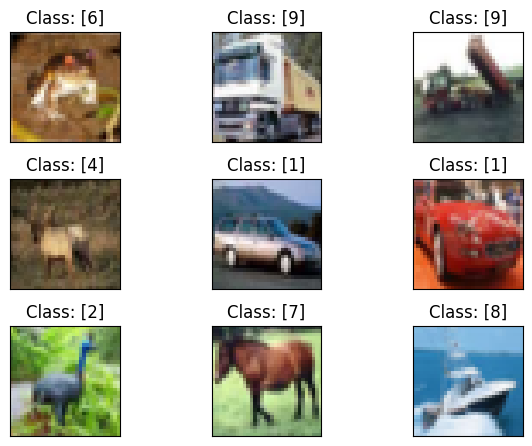

In [4]:
fig = plt.figure()

for i in range(9):
  plt.subplot(3, 3, i+1)
  plt.tight_layout()
  plt.imshow(X_train_full[i], interpolation='none')
  plt.title('Class: {}'.format(y_train_full[i]))
  plt.xticks([])
  plt.yticks([])

In [5]:
tf.random.set_seed(20)

In [6]:
from tensorflow import Tensor
from tensorflow.keras.layers import Input, Conv2D, ReLU, BatchNormalization,\
                                    Add, AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# **The model:**

Inspired by AlexNet, this model is used for 32 x 32 colored image classification trained by CIFAR10 dataset downloaded from keras datasets:

The model uses three Conv2D layers with Average Pooling2D in between every pair of Conv2D layers and one FC layer in the end. (See the model's map below.)

In [7]:
K.clear_session()

model = keras.models.Sequential([
  keras.Input(shape=(32,32,3)),

  keras.layers.Conv2D(filters = 96,
                      kernel_size = 5,
                      strides = 1,
                      padding='same',
                      activation = 'relu'),

  BatchNormalization(),

  keras.layers.AveragePooling2D(pool_size = 2),

  keras.layers.Dropout(0.25),

  keras.layers.Conv2D(filters = 64,
                      kernel_size = 3,
                      strides = 1,
                      padding='same',
                      activation = 'relu'),

  BatchNormalization(),

  keras.layers.AveragePooling2D(pool_size = 2),

  keras.layers.Dropout(0.25),

  keras.layers.Conv2D(filters = 32,
                      kernel_size = 3,
                      strides = 1,
                      padding='same',
                      activation = 'relu'),

  BatchNormalization(),

  keras.layers.AveragePooling2D(pool_size = 2),

  keras.layers.Dropout(0.25),

  keras.layers.Flatten(),
  keras.layers.Dense(units = 100,
                     activation = 'relu'),

  keras.layers.Dense(units = 10,
                     activation = 'softmax')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0025)

earlyStopping_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=7)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 96)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 4, 4, 32)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,198 (524.21 KB)

 Trainable params: 133,814 (522.71 KB)

 Non-trainable params: 384 (1.50 KB)

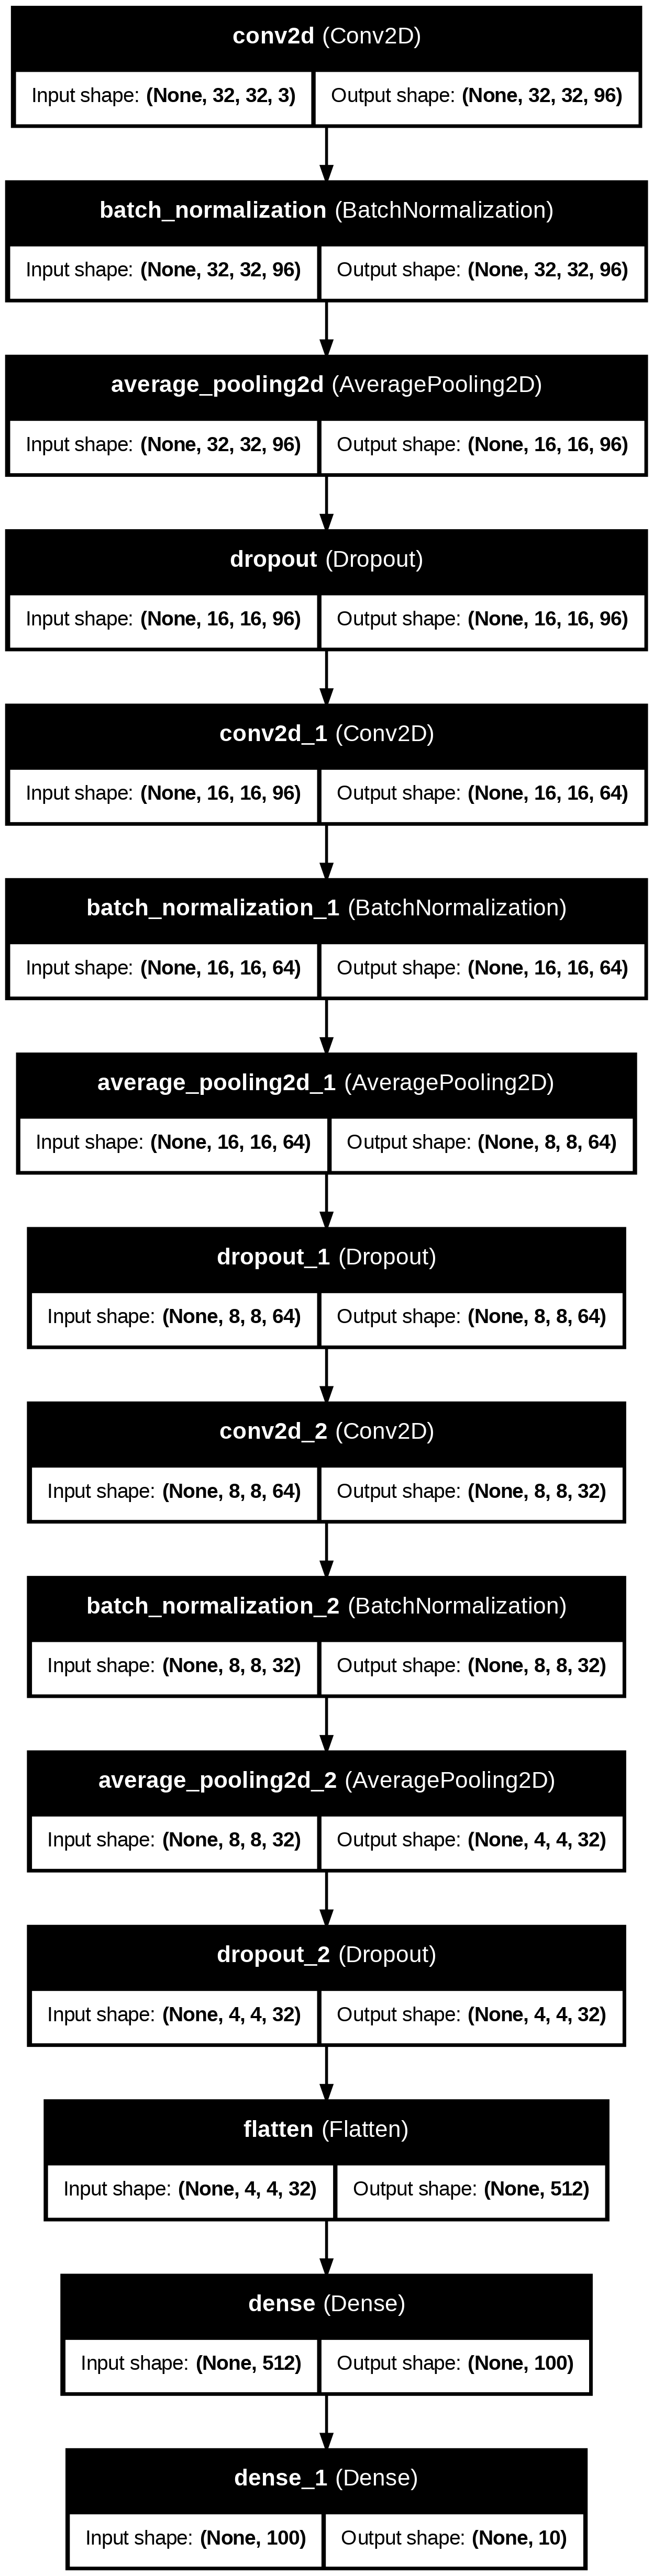

In [8]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='pic.png',
    show_shapes=True,
    show_layer_names=True)

In [9]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

history = model.fit(X_train_full,y_train_full,batch_size=32,epochs=150,validation_split=0.1, callbacks=[tensorboard_callback, earlyStopping_callback])

Epoch 1/150
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.3973 - loss: 1.6840 - val_accuracy: 0.5582 - val_loss: 1.2441
Epoch 2/150
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5744 - loss: 1.2042 - val_accuracy: 0.5766 - val_loss: 1.2014
Epoch 3/150
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6321 - loss: 1.0364 - val_accuracy: 0.6478 - val_loss: 1.0125
Epoch 4/150
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6697 - loss: 0.9319 - val_accuracy: 0.6788 - val_loss: 0.9290
Epoch 5/150
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6951 - loss: 0.8661 - val_accuracy: 0.7294 - val_loss: 0.8111
Epoch 6/150
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7140 - loss: 0.8144 - val_accuracy: 0.7202 - val_loss: 0.8278
Epoch 7/150
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7247 - loss: 0.7812 - val_accuracy: 0.7380 - val_loss: 0.7678
Epoch 8/150
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7368 - loss: 

# **Model's accuracy history**

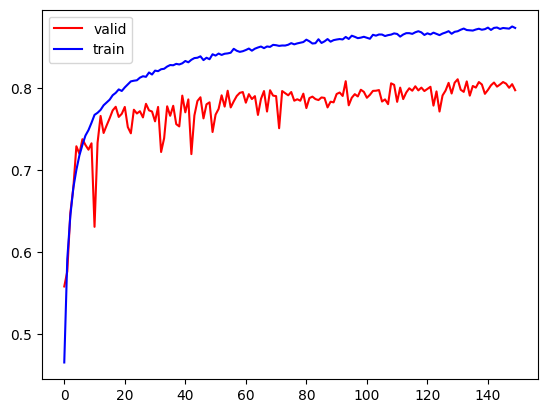

In [10]:
plt.plot(history.history['val_accuracy'], 'r')
plt.plot(history.history['accuracy'], 'b')
plt.legend(['valid', 'train'])

In [11]:
X_test_predict = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [12]:
max_index_test_predict = np.argmax(X_test_predict, axis=1).reshape(10000, 1)

print("Test_accuracy = ", float(np.count_nonzero((y_test == max_index_test_predict)))/10000)

Test_accuracy =  0.7903


# **Report of Model's Train/Validation/Test Acurracy:**

Training accuracy: 0.8708

Validation accuracy: 0.7978

Test accuracy: 0.7903